In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
# Load dataset directly from the current folder
df = pd.read_csv('Churn_Modelling.csv')

# Drop unused columns (RowNumber, CustomerId, Surname)
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Rename 'Exited' to 'Churn' for consistency
df.rename(columns={'Exited': 'Churn'}, inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# One-hot encode categorical text variables (Geography and Gender)
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"Total features created: {X.shape[1]}")

Total features created: 11


In [9]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 8000 rows
Testing set: 2000 rows


In [10]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate predictions
y_pred = rf_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Accuracy: 86.40%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



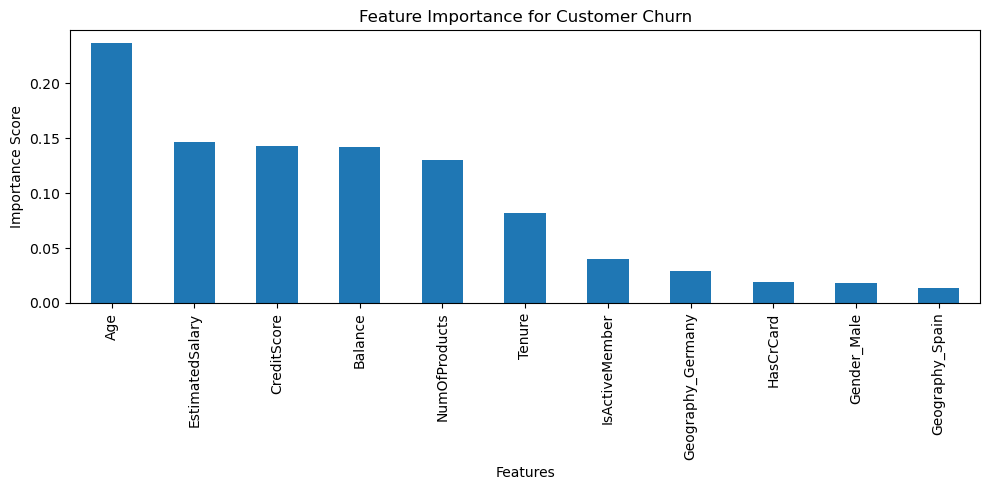

In [11]:
# Extract feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 5))
importances.plot(kind='bar')
plt.title('Feature Importance for Customer Churn')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()